In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

sns.set() 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6 
plt.rcParams['font.size'] = 14 
plt.rcParams['axes.unicode_minus'] = False 

# 결측치 시각화를 위한 라이브러리
import missingno 

# 데이터 전처리 알고리즘 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 

# 학습용과 검증용으로 나누는  함수 
from sklearn.model_selection import train_test_split 

# 교차검증 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한도구 
from sklearn.model_selection import GridSearchCV 

# 머신러닝 알고리즘 - 분류 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from lightgbm import LGBMClassifier 
from xgboost import XGBClassifier 
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet 
from sklearn.svm import SVR 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from lightgbm import LGBMRegressor 
from xgboost import XGBRegressor 
from sklearn.ensemble import VotingRegressor 

# 학습 모델 저장을 위한 라이브러리
import pickle 

In [3]:
customers = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_order_items_dataset.csv")
order_payments = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_order_reviews_dataset.csv", encoding="latin1")
orders = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_orders_dataset.csv") 
products = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_products_dataset.csv")
sellers = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\프로젝트\브라질 이커머스 데이터 분석 프로젝트'\olist dataset\olist_sellers_dataset.csv") 

In [ ]:
# Merge orders + customers
df = orders.merge(customers, on='customer_id', how='left')

In [5]:
# Filtering only delivered orders with non-null delivery dates
df = df[
    (df["order_status"] == "delivered") &
    (df["order_delivered_customer_date"].notna())
].copy()

In [6]:
# Coverting timestamps to datetime and caculating delivery days 
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

In [7]:
# Removing negative values in delivery days 
df = df[
    (df["delivery_days"] >= 0)
].copy()

In [8]:
# Sorted by Average Delivery Days by State
state_order = (
    df.groupby("customer_state")["delivery_days"]
    .median()
    .sort_values()
    .index
)

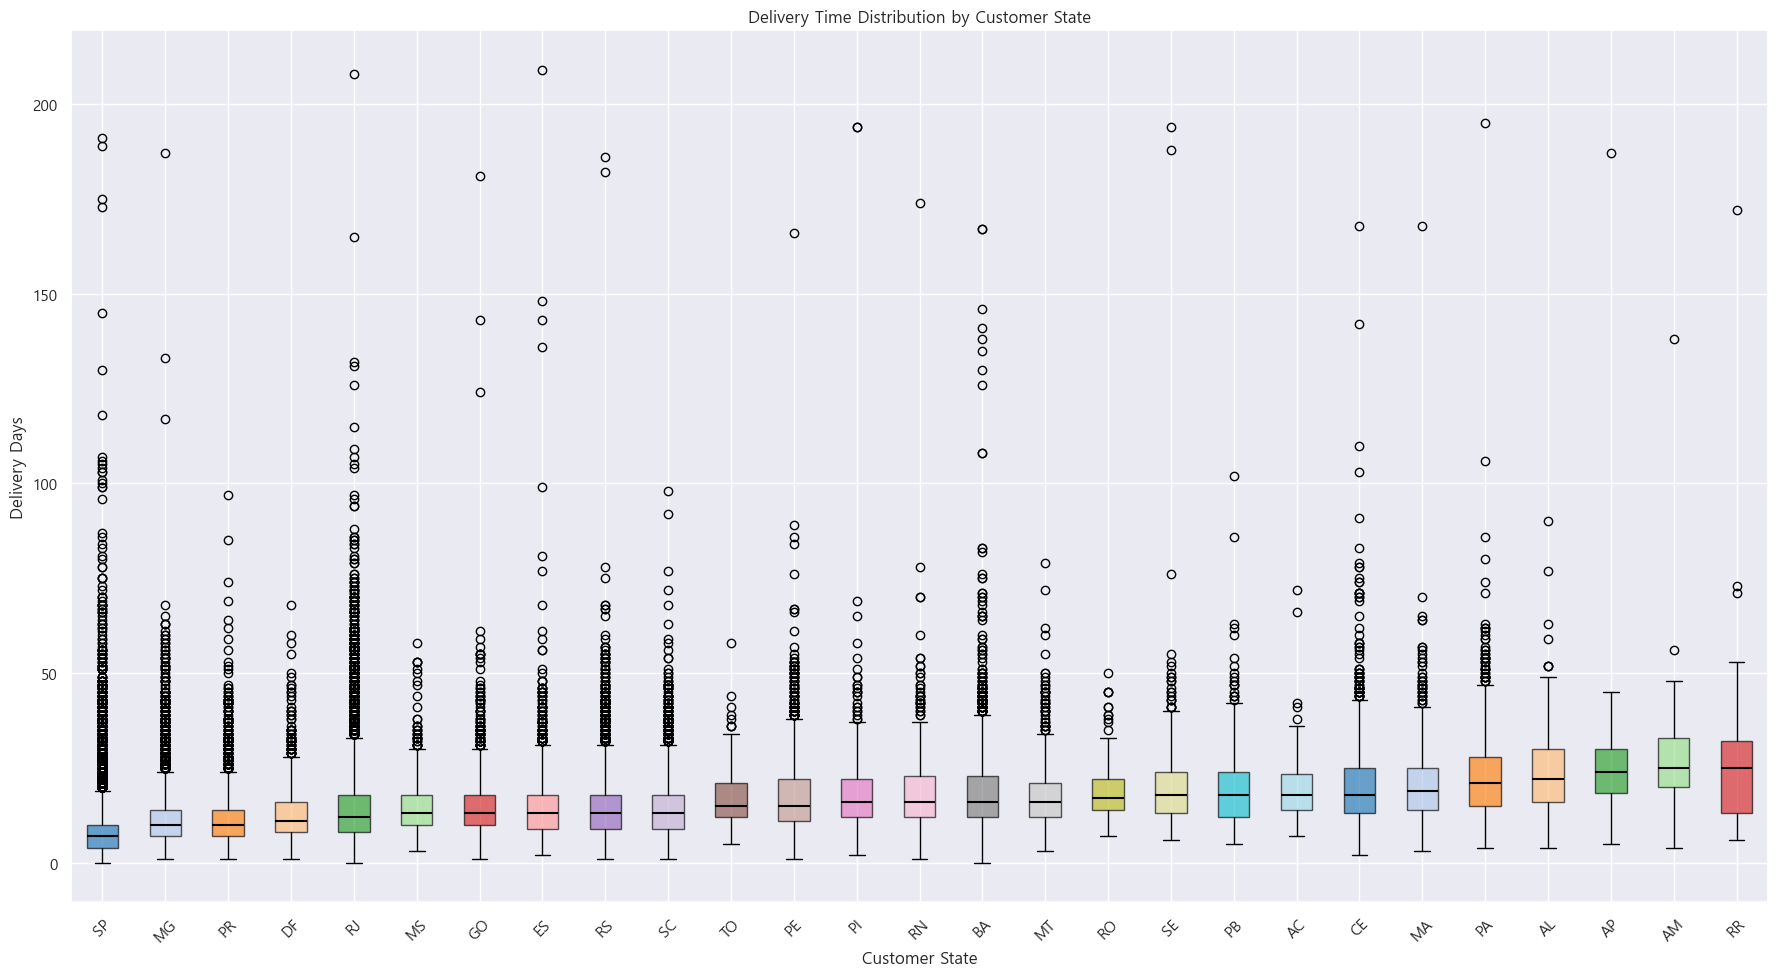

In [ ]:
# Boxplot of Delivery Days by Customer State


# 배송일수 중앙값 기준으로 높은 순 정렬
state_order = (
    df.groupby("customer_state")["delivery_days"]
      .median()
      .sort_values(ascending=True)
      .index
)

# 정렬된 순서대로 데이터 만들기
data = [
    df.loc[df["customer_state"] == state, "delivery_days"]
    for state in state_order
]

box = plt.boxplot(
    data,
    labels=state_order,
    showfliers=True,
    patch_artist=True,
)

colors = plt.cm.tab20.colors

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.65)
    patch.set_edgecolor("black")

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

plt.title("Delivery Time Distribution by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Delivery Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delivery time varies significantly by customer state, and several states show a large number of extreme outliers, suggesting that regional logistics bottlenecks may be driving long-tail delivery delays.

배송일수 중앙값 기준으로 주별 차이가 뚜렷하게 나타나며, RJ·BA·SP 등 일부 지역은 이상치가 많이 분포해 장기 배송 지연 리스크가 존재한다.

In [ ]:
import geopandas as gpd

# 브라질 지도 배경 불러오기 
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

brazil = world[world["NAME"] == "Brazil"]

In [ ]:
# geolocation은 zip 하나에 여러 좌표가 있어서 평균 좌표로 축소 
geo_customer = ( 
    geolocation
    .groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)

In [ ]:
# customer 데이터에 좌표 붙이기 
customer_geo = customers.merge(
    geo_customer,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

In [ ]:
# seller 데이터에 좌표 붙이기
seller_geo = sellers.merge(
    geo_customer,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

In [28]:
# orders랑 병합 
df_map = orders.merge(customer_geo, on='customer_id', how='left')

In [29]:
# 배송 완료 주문만 필터링 
df_map = df_map[
    (df_map["order_status"] == "delivered") &
    (df_map["geolocation_lat"].notna()) &
    (df_map["geolocation_lng"].notna())
].copy()

Orders + order_items + sellers 병합 

In [53]:
# orders + order_items + sellers 병합
seller_order_map = (
    orders
    .merge(order_items, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

In [55]:
# seller zip 기준으로 좌표 붙이기
seller_order_map = seller_order_map.merge(
    geo_customer,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

In [56]:
# 배송완료 + 좌표 있는 주문만 필터링
seller_order_map_clean = seller_order_map[
    (seller_order_map["order_status"] == "delivered") &
    (seller_order_map["geolocation_lat"].notna()) &
    (seller_order_map["geolocation_lng"].notna())
].copy()

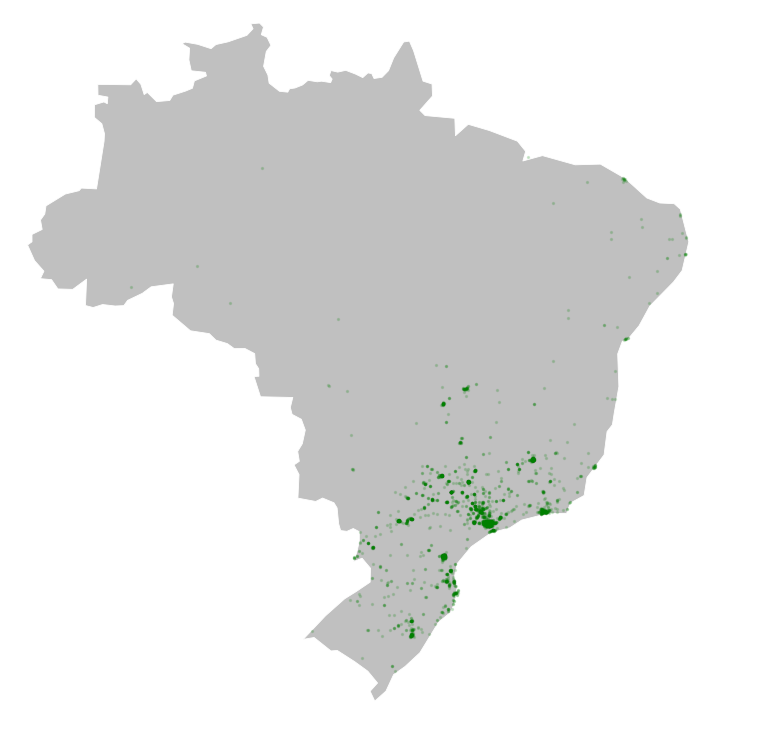

In [89]:
# seller 위치 분포 지도 그리기
fig, ax = plt.subplots(figsize=(8, 10))

# 전체 배경 흰색으로
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 브라질 지도 배경
brazil.plot(
    ax=ax,
    color="#c0c0c0",
    edgecolor="white",
    linewidth=0.6
)

# 판매자 위치 분포
ax.scatter(
    seller_geo["geolocation_lng"],
    seller_geo["geolocation_lat"],
    s=2,
    alpha=0.15,
    color="green",
    label="Sellers"
)

ax.set_title("")

# 브라질만 보이게 범위 조정
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)

# 축, 눈금, 격자 제거
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

# 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

# 범례 제거하고 싶으면 이 줄은 빼기
# ax.legend()

plt.tight_layout()
plt.show()

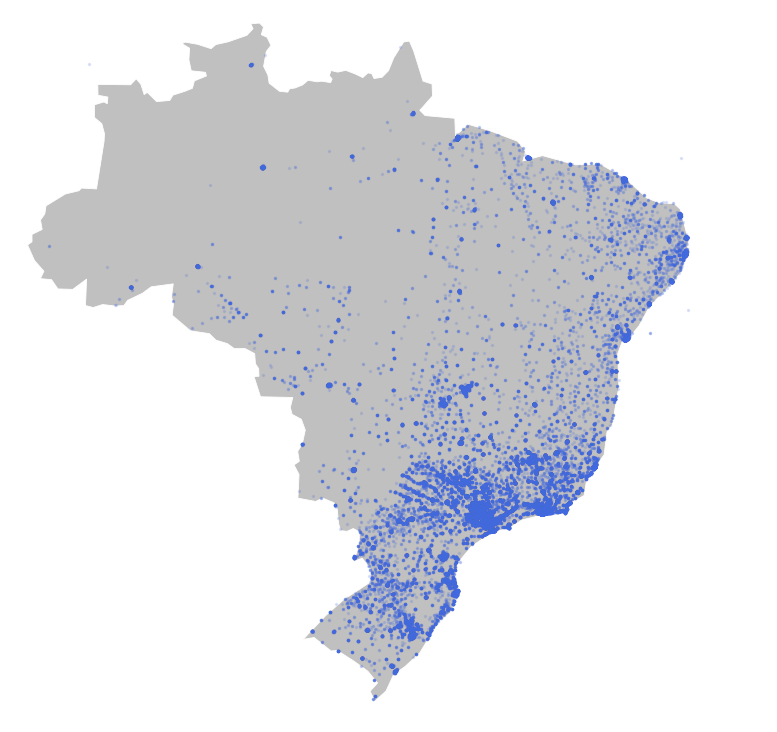

In [88]:
# customer 위치 분포 지도 그리기
fig, ax = plt.subplots(figsize=(8, 10))

# 전체 배경 흰색으로
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 브라질 지도 배경
brazil.plot(
    ax=ax,
    color="#c0c0c0",
    edgecolor="white",
    linewidth=0.6
)

# 고객 위치 분포
ax.scatter(
    customer_geo["geolocation_lng"],
    customer_geo["geolocation_lat"],
    s=2,
    alpha=0.15,
    color="royalblue",
    label="Customers"
)

ax.set_title("" )

# 브라질만 보이게 범위 조정
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)

# 축, 눈금, 격자 제거
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

# 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

# 범례 제거하고 싶으면 이 줄은 빼기
# ax.legend()

plt.tight_layout()
plt.show()

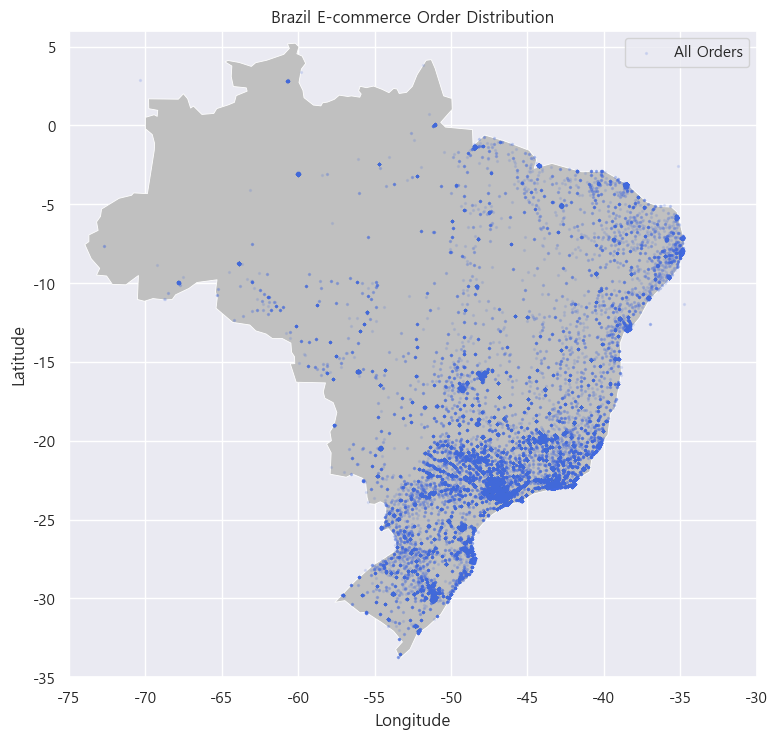

In [48]:
# 전체 주문 분포 지도 
fig, ax = plt.subplots(figsize=(8, 10))

# 브라질 지도 배경
brazil.plot(
    ax=ax,
    color="#c0c0c0",
    edgecolor="white",
    linewidth=0.6
)

# 전체 주문 분포
ax.scatter(
    df_map["geolocation_lng"],
    df_map["geolocation_lat"],
    s=2,
    alpha=0.12,
    color="royalblue",
    label="All Orders"
)

ax.set_title("Brazil E-commerce Order Distribution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# 브라질만 보이게 범위 조정
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)

plt.tight_layout()
plt.show()

In [31]:
# 지연 주문만 따로 표시 
df_map["order_purchase_timestamp"] = pd.to_datetime(df_map["order_purchase_timestamp"])
df_map["order_delivered_customer_date"] = pd.to_datetime(df_map["order_delivered_customer_date"])

df_map["delivery_days"] = (
    df_map["order_delivered_customer_date"] - df_map["order_purchase_timestamp"]
).dt.days

In [32]:
# 30일 초과를 장기 지연으로 임의 설정
delayed_map = df_map[df_map["delivery_days"] > 30].copy()

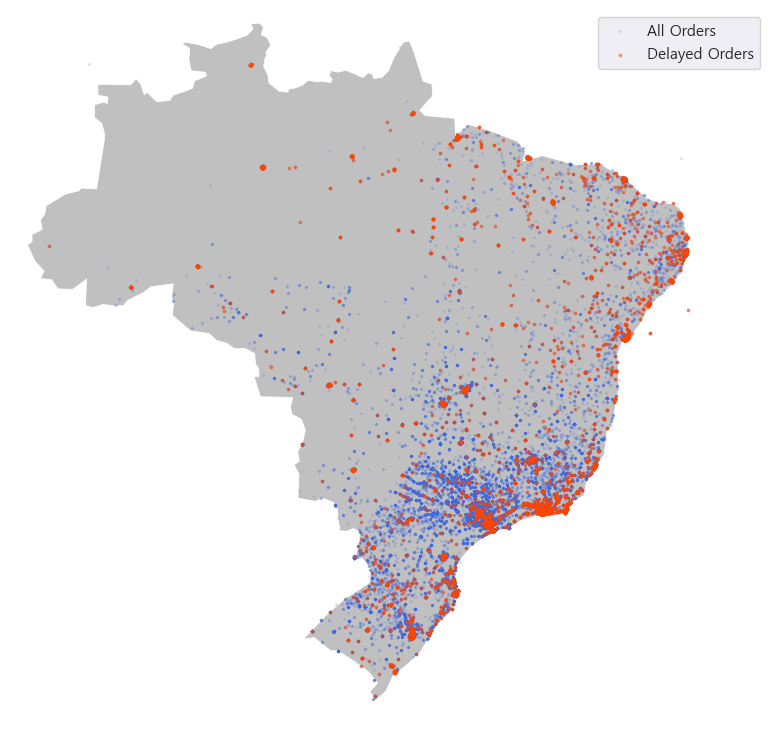

In [91]:
# customer 위치 분포 지도 그리기
fig, ax = plt.subplots(figsize=(8, 10))

# 전체 배경 흰색으로
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 브라질 지도 배경
brazil.plot(
    ax=ax,
    color="#c0c0c0",    
    edgecolor="white",
    linewidth=0.6
)

# 전체 주문
ax.scatter(
    df_map["geolocation_lng"],
    df_map["geolocation_lat"],
    s=2,
    alpha=0.12,
    color="royalblue",
    label="All Orders"
)

# 지연 주문
ax.scatter(
    delayed_map["geolocation_lng"],
    delayed_map["geolocation_lat"],
    s=3,
    alpha=0.45,
    color="orangered",
    label="Delayed Orders"
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.legend()

# 브라질만 보이게 범위 조정
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)

plt.tight_layout()
plt.show()

주별 delivery days 분포

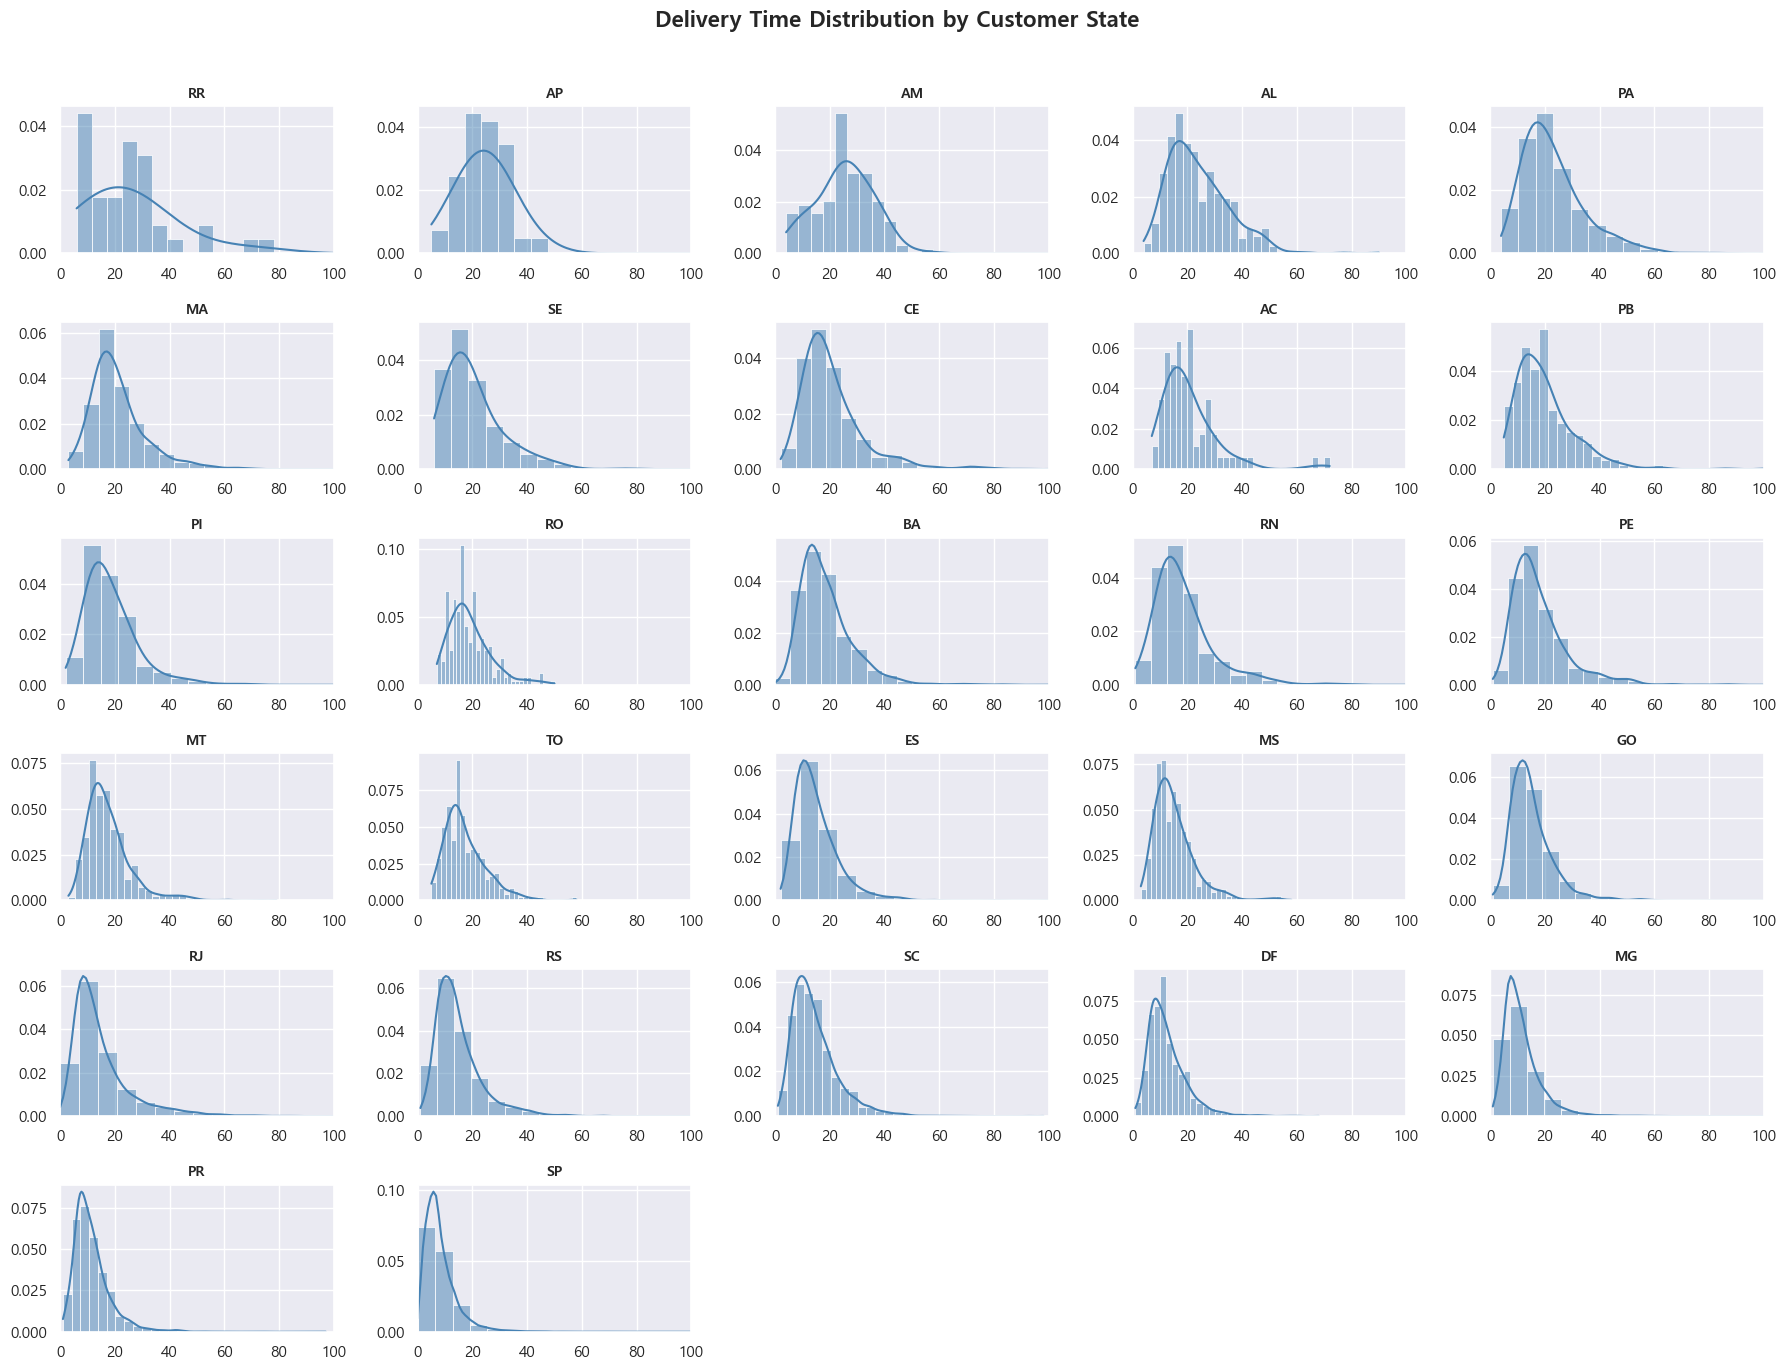

In [80]:
# 배송일수 결측제거 
plot_df = df[["customer_state", "delivery_days"]].dropna().copy()

# 평균 배송일 기준 정렬 
state_order = ( 
    plot_df.groupby("customer_state")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
    .index 
)

states = list(state_order)

 # subplot grid 설정
n_cols = 5
n_rows = int(np.ceil(len(states) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, state in enumerate(states):
    ax = axes[i]
    sub = plot_df[plot_df["customer_state"] == state]

    sns.histplot(
        sub["delivery_days"],
        bins=30,
        stat="density",
        kde=True,
        color="steelblue",
        ax=ax
    )

    ax.set_title(state, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

# 남는 subplot 지우기
for j in range(len(states), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Delivery Time Distribution by Customer State", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


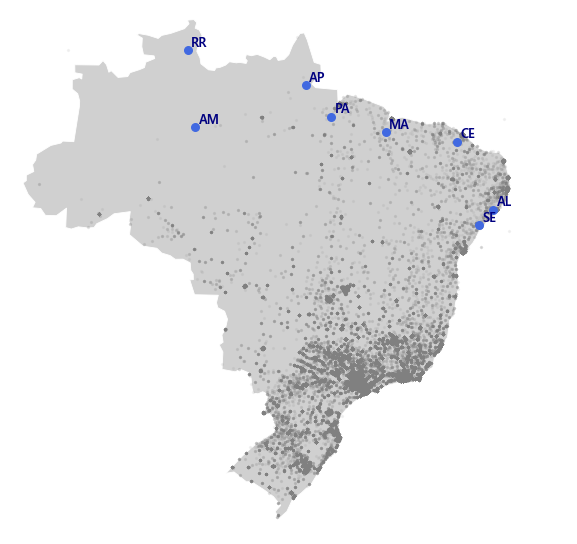

In [86]:
import geopandas as gpd


# 주별 평균 배송일
state_delay = (
    df_map.groupby("customer_state")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 평균 배송일 상위 8개 주
top_states = state_delay.head(8)["customer_state"].tolist()

# 각 주의 대표 좌표(평균 좌표)
state_centroids = (
    df_map.groupby("customer_state")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)

top_centroids = state_centroids[state_centroids["customer_state"].isin(top_states)]

fig, ax = plt.subplots(figsize=(6, 8))

# 전체 배경 흰색으로
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

brazil.plot(ax=ax, color="#d0d0d0", edgecolor="white", linewidth=0.6)

# 전체 고객 점은 연하게
ax.scatter(
    df_map["geolocation_lng"],
    df_map["geolocation_lat"],
    s=2,
    alpha=0.08,
    color="gray"
)

# 문제 주 라벨 표시
for _, row in top_centroids.iterrows():
    ax.scatter(row["geolocation_lng"], row["geolocation_lat"], color="royalblue", s=30)
    ax.text(
        row["geolocation_lng"] + 0.3,
        row["geolocation_lat"] + 0.3,
        row["customer_state"],
        fontsize=9,
        color="navy",
        weight="bold"
    )

ax.set_title("")
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 6)
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()